<a href="https://colab.research.google.com/github/VALESOLCORTEZ/ABP-M-dulo-Analista-de-Datos-1/blob/main/Clase_5_(COM_B)_Gr%C3%A1ficos_(An%C3%A1lisis_de_Datos).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS GRÁFICO.
Modulo: Analista de Datos I

Materia: Procesamiento de Datos

Prof. Yamil Salomon

# IMPORTACION DE LIBRERÍAS

1.   **Pandas** sirve para trabajar con datos de forma organizada en Python, especialmente tablas, archivos Excel, CSV y bases de datos.
2.   **NumPy** sirve para trabajar con números y cálculos de forma rápida en Python, especialmente cuando manejásse manejan muchos datos. Ejemplo: se usa para vectores y matrices, operaciones matemáticas rápidas, álgebra, estadística.
3.  **Matplotlib** se usa para gráficos de líneas
Barras, Torta/circular, Histogramas, Dispersión (scatter)
Subgráficos y permite una Personalización total de títulos, colores y ejes **(Importación Matplotlib para la visualización).**
4. **Seaborn** hace gráficos más modernos, lindos y simples, especialmente para análisis estadístico **(Importación para visualización avanzada).**
5. **Math** sirve para importar la librería matemática estándar de Python. Permite usar funciones y constantes matemáticas avanzadas que no vienen disponibles directamente en Python básico como por ejemplo: raices y potencias, funciones trigonométricas, redondeos especiales, funciones logaritmicas y exponenciales, et.

In [ ]:
# Importación de Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import missingno as msno
import re

## Importar un dataset csv desde drive (url)

**!gdown** no es exactamente un método de Python, sino un comando de sistema que se ejecuta dentro de Google Colab o Jupyter Notebook.

📌 ¿Qué significa?
El signo ! indica que se va a ejecutar un comando externo (como en la terminal).
gdown es una herramienta que sirve para descargar archivos desde Google Drive usando un enlace o ID del archivo.

De la URL estraída del drive (carpeta compartida de "archivos de trabajo" que les deje en la plataforma):

https://drive.google.com/file/d/1kdmE9m19oNJuuoqsxOqskgdMOojVE4cv/view?usp=drive_link


se toma solamente la parte que se encuentra entre barras "1TCvFgqJf32VpjuBzNWTqApn8LYuUHzBm" y se la escribe despues del comando **!gdown**

La fuente original fue extraía de kaggle
https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster?rvi=1

In [ ]:
### Importar un dataset csv desde drive (url)
###
!gdown 1kdmE9m19oNJuuoqsxOqskgdMOojVE4cv


Downloading...
From: https://drive.google.com/uc?id=1kdmE9m19oNJuuoqsxOqskgdMOojVE4cv
To: /content/ObesityDataSet.csv
100% 264k/264k [00:00<00:00, 77.4MB/s]


## **Acerca del conjunto de datos**

Este conjunto de datos incluye información para la estimación de los niveles de obesidad en individuos de México, Perú y Colombia, basada en sus hábitos alimenticios y condición física. Los datos contienen 17 atributos y 2111 registros, etiquetados con la variable de clase NObesity (Nivel de Obesidad), que permite la clasificación/agrupación/regresión de los datos utilizando los valores de Peso Insuficiente, Peso Normal, Sobrepeso Nivel I, Sobrepeso Nivel II, Obesidad Tipo I, Obesidad Tipo II y Obesidad Tipo III.

## **Diccionario de datos "Variables**

* Gender --- > Género
* Age ---> Edad
* Height ---> Altura
* Weight ---> Peso
* family_history_with_overweight ---> Antecedentes familiares de sobrepeso
* FAVC ---> Consumo frecuente de alimentos altos en calorías
* FCVC ---> Frecuencia de consumo de verduras
* NCP ---> Número de comidas principales
* CAEC ---> Consumo de alimentos entre comidas
* SMOKE ---> Fumador o no
* CH2O ---> Consumo diario de agua
* SCC ---> Monitoreo del consumo de calorías
* FAF ---> Frecuencia de actividad física
* TUE ---> Tiempo utilizando dispositivos tecnológicos
* CALC ---> Consumo de alcohol
* MTRANS ---> Medio de transporte utilizado
* NObeyesdad ---> Nivel de obesidad deducido

## **Análisis de Dataset**

In [ ]:
#revisamos previamente el dataset y tiene separador de comas que por defecto Python puede levantar; tambien tiene encabezados
df = pd.read_csv('ObesityDataSet.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [ ]:
# Utilizamos el método head para visualizar las primeras filas del df
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
# Utilizamos el método shape para observar la dimensionalidad de nuestro dataset (cantidad de filas y columnas)
df.shape

(2111, 17)

In [ ]:
# Utilizamos el método columnas para imprimir todas las columnas de nuestro df
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [ ]:
# Renombraremos las columnas del df
# Creamos un diccionario al que le pasaremos el nombre de las columnas del dataframe como llaves
# Los nombres nuevos de las columnas se las pasaremos como los valores
nombres_nuevos = {'Gender': 'Género','Age': 'Edad','Height': 'Altura','Weight': 'Peso',
                'family_history_with_overweight': 'Antecedentes_familiares_sobrepeso',
                'FAVC': 'Consumo_frec_alimentos_altos_calorías','FCVC': 'Frecuencia_consumo_verduras',
                'NCP': 'Número_comidas_principales','CAEC': 'Consumo_alimentos_entre_comidas',
                'SMOKE': 'Fumador','CH2O': 'Consumo_agua_diario','SCC': 'Monitoreo_consumo_calorías',
                'FAF': 'Frec_actividad_física','TUE': 'Tiempo_uso_dispositivos_tecnológicos',
                'CALC': 'Consumo_alcohol','MTRANS': 'Medio_transporte_utilizado','NObeyesdad': 'Nivel_obesidad'
                 }

In [ ]:
# Utilizamos el método rename para renombrar
# llamamos a df le pasamos el método rename y los argumentos que deseamos renombrar, en este caso columns
# a columns le asignamos el diccionario con los nombres nuevos
# Utilizamos el arguemto inplace=True para cambiar directamnete el df original
df.rename(columns=nombres_nuevos, inplace=True)

In [ ]:
# Vamos a revisar la información (con el método info observamos los datos no nulos y verificamos si existen)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Género                                 2111 non-null   object 
 1   Edad                                   2111 non-null   float64
 2   Altura                                 2111 non-null   float64
 3   Peso                                   2111 non-null   float64
 4   Antecedentes_familiares_sobrepeso      2111 non-null   object 
 5   Consumo_frec_alimentos_altos_calorías  2111 non-null   object 
 6   Frecuencia_consumo_verduras            2111 non-null   float64
 7   Número_comidas_principales             2111 non-null   float64
 8   Consumo_alimentos_entre_comidas        2111 non-null   object 
 9   Fumador                                2111 non-null   object 
 10  Consumo_agua_diario                    2111 non-null   float64
 11  Moni

**1. Estructura General del Dataset**

  * Total de entradas: El conjunto de datos tiene 2,111 filas (índices del 0 al 2110).

  * Total de columnas: Hay 17 columnas en total.

  * Integridad de los datos: Todas las columnas muestran 2,111 non-null, lo que significa que no hay valores faltantes (está "limpio" en términos de nulidad).

**2. Tipos de Datos (Dtypes)**
El dataset está equilibrado entre datos numéricos y categóricos:

  * float64 (8 columnas): Datos numéricos decimales como Edad, Altura, Peso, Frecuencia_consumo_verduras, Número_comidas_principales, Consumo_agua_diario, Frec_actividad_física y Tiempo_uso_dispositivos_tecnológicos.

  * object (9 columnas): Generalmente texto o categorías, como Genero, Antecedentes_familiares_sobrepeso, Fumador, Consumo_alcohol, y la variable objetivo Nivel_obesidad.

**3. Variables Clave Identificadas**
El estudio analiza factores como:

  * Datos antropométricos: Edad, altura y peso.

  * Hábitos: consumo de agua (CH2O), frecuencia de actividad física (FAF), tiempo utilizando dispositivos tecnológicos (TUE), tabaquismo (SMOKE) y consumo de alcohol (CALC).

  * Alimentación: frecuencia de consumo de verduras (FCVC), número de comidas principales (NCP) y consumo de alimentos calóricos (FAVC), consumo de alimentos entre comidad (CAEC).

  * Variable Objetivo: Nivel de obecidad, que probablemente clasifica el nivel de obesidad del individuo.

Recordemos el tipo de variable que podemos tener:

| Tipo de dato | dtype en pandas |
| ------------ | --------------- |
| Entero       | int64           |
| Decimal      | float64         |
| Texto        | object / string |
| Booleano     | bool            |
| Fecha        | datetime64      |
| Categoría    | category        |


In [ ]:
# Verificación datos nulos
contar_datos_nulos = df.isnull().sum()
contar_datos_nulos

,0
Género,0
Edad,0
Altura,0
Peso,0
Antecedentes_familiares_sobrepeso,0
Consumo_frec_alimentos_altos_calorías,0
Frecuencia_consumo_verduras,0
Número_comidas_principales,0
Consumo_alimentos_entre_comidas,0
Fumador,0


In [ ]:
# Utilizamos el método describe para hacer un resumen de analisis estadistico del df
df.describe()

,Edad,Altura,Peso,Frecuencia_consumo_verduras,Número_comidas_principales,Consumo_agua_diario,Frec_actividad_física,Tiempo_uso_dispositivos_tecnológicos
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Puntos más relevantes:

**1. Estadísticas Generales**
  
  * count (Conteo): Todas las columnas tienen 2111 registros, lo que confirma que no hay valores nulos en estas variables numéricas.

  * mean (Promedio): Nos da una idea del "centro" de los datos. Por ejemplo, la edad promedio es de 24.3 años y el peso promedio es de 86.5 kg.

  * std (Desviación estándar): Indica qué tan dispersos están los datos respecto al promedio. En el peso (Weight), la desviación es alta (26.19), lo que sugiere una gran variedad de tallas en el grupo.

**2. Perfil de la Población (Basado en los Cuartiles)**
El cuadro divide los datos en porcentajes para entender la distribución:

  * Edad (Age): La persona más joven tiene 14 años (min) y la mayor 61 años (max). Sin embargo, el 75% de los participantes tiene 26 años o menos, lo que indica que es una población mayoritariamente joven.

  * Estatura (Height): Oscila entre 1.45m y 1.98m, con una mediana (50%) de 1.70m.

  * Peso (Weight): Hay un rango muy amplio, desde los 39 kg hasta los 173 kg.

**3. Hábitos y Estilo de Vida**
Estas variables suelen estar en escalas (por ejemplo, de 1 a 3 o de 0 a 3):

  * CH2O (Consumo de agua): El promedio es de 2.00, lo que sugiere que la mayoría consume alrededor de 2 litros de agua al día.

  * FAF (Actividad física): El valor mínimo es 0 (sedentarismo total) y el máximo es 3. El promedio es de 1.01, indicando niveles de actividad moderados a bajos para gran parte de la muestra.

  * TUE (Uso de dispositivos tecnológicos): Con un máximo de 2, el promedio de 0.65 sugiere que el tiempo frente a pantallas varía bastante entre los sujetos.

**¿Qué nos dice esto en conjunto?**
Nos dice que estamos analizando un grupo de jóvenes adultos con una diversidad física considerable (especialmente en peso). Los datos están bien distribuidos y listos para identificar patrones entre estos hábitos (agua, ejercicio, tecnología) y el estado físico de las personas.

# **ANALISIS GRÁFICO**

## **Histograma**

1. Utilizaremos el histograma para visualizar le frecuencia de la variable cuantitativa peso.

2. Este gráfico muestras los valores de pesos agrupados en los intervalos "bins". En este caso los bins son calculados con el peso minimo y maximo, utilizamos el método np.ceil para asegurarnos de que los números de bins sean números enteros, esto lo redondeara hacia arriba para evitar intervalos fraccionales. La formula de cálculo es Número de bins: k = (max(x) - min(x)) / h.
3. Los bins tiene una ancho de 5 puntos.
4. Cada intervalo se grafica como una barra y su altura corresponde a la cantidad de observaciones que caen dentro de ese intervalo.
5. Definimos un lienzo de tamaño 8 * 3.
6. Llamamos al método hist de matplotlib, asiganmos la variable "columna" peso del datafram, pasamos como argumentos la variable n_bins que hemos calculado anteriormente para pasar el número adecuado de bins en este caso son 27.
7. Pasamos como argumento color para proporcionar el valor de skyblue.
8. Asigamos edgecolor con un valor de white para el borde de las barras del histograma, esto nos proporciona mejor division entre las barras, diferencia.
9. Asiganmos un alpha de 0.8 es decir un grado de opacidad.
10. Asignamos los grid con valor True para mostrar las grillas del grafico.

In [ ]:
# Definimos el número del bins (intervalos) para el histograma
min_peso = min(df["Peso"])
max_peso = max(df["Peso"])
bin_width = 5 # Ajustar el ancho de los bins según tu preferencia
n_bins = int(np.ceil((max_peso - min_peso) / bin_width))
print(f"El número calculado de bins con un ancho de {bin_width} es: {n_bins}")

El número calculado de bins con un ancho de 5 es: 27


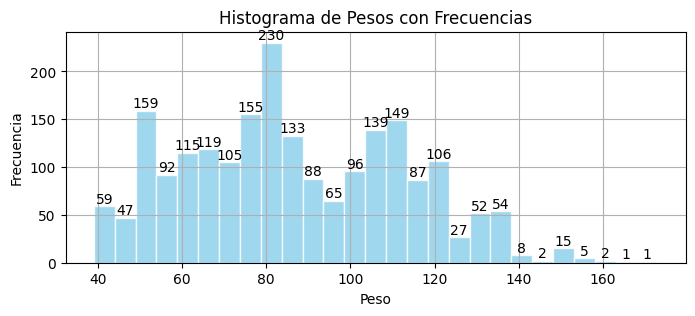

In [ ]:
# Definimos el tamaño del lienzo 8 * 3
plt.figure(figsize=(8, 3))

# Llamamos al método hist para el histograma, pasamos la variable peso y los argumentos bins que contiene la cantidad de
# bins definidos anteriormente, argumentamos el color con el valor de skyblue y el margen con white, y una opacidad de 0.8
# Capturamos los valores de n (frecuencias) y bins (bordes de los bins)
n, bins, patches = plt.hist(df["Peso"], bins=n_bins, color='skyblue', edgecolor="white", alpha=0.8)

# Definimos el título del gráfico
plt.title('Histograma de Pesos con Frecuencias')
# Definimos la etiqueta del eje x
plt.xlabel('Peso')
# Definimos la etiqueta del eje y
plt.ylabel('Frecuencia')

# Añadir etiquetas de frecuencia en la parte superior de cada barra
for i in range(len(n)):
    if n[i] > 0: # Solo mostrar etiquetas para barras con frecuencia > 0
        plt.text(bins[i] + (bins[i+1] - bins[i]) / 2, n[i], str(int(n[i])), ha='center', va='bottom')

# Definimos grillas para el gráfico
plt.grid(True)
# Imprimimos el gráfico
plt.show()

***INTERPRETACION***

  * Este histograma permite interpretar cómo se distribuyen los pesos dentro del conjunto de datos y muestra cuáles son los rangos más frecuentes y cuáles tienen menor representación.

  * Se observa que la mayor concentración de datos se encuentra entre aproximadamente 50 y 120 unidades de peso, lo que indica que la mayoría de las observaciones pertenece a ese rango. En particular, el intervalo cercano a 80 presenta la frecuencia más alta, alcanzando alrededor de 230 observaciones, por lo que puede considerarse el rango modal o predominante de la distribución.

  * También se identifican otros intervalos con frecuencias elevadas, como los cercanos a 50, 75, 105 y 110, lo que sugiere que existen varios grupos de pesos con fuerte presencia dentro de la muestra. Esto podría indicar una distribución multimodal o la existencia de distintos segmentos en la población analizada.

  * Por otro lado, a medida que los valores de peso aumentan por encima de 130, la frecuencia disminuye considerablemente. Los pesos cercanos a 150, 160 y superiores aparecen con muy pocas observaciones, lo que evidencia que son casos poco frecuentes o posibles valores extremos dentro del conjunto de datos.

  * Además, el gráfico presenta una ligera asimetría hacia la derecha, ya que existe una cola de valores altos con baja frecuencia. Esto indica que, aunque la mayoría de los pesos se concentra en valores medios, existen algunos registros significativamente mayores que el promedio.

Vamos a generar histogramas de frecuencia de Peso en función del Género

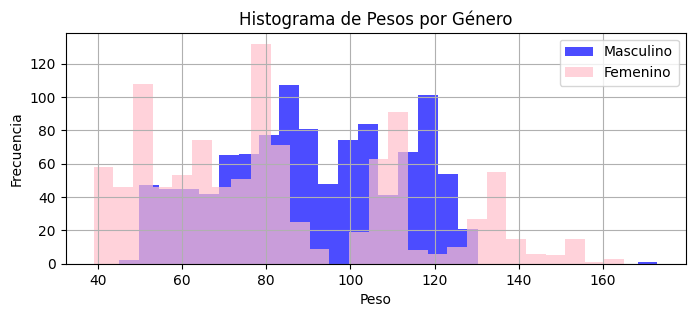

In [ ]:
# Definir el número adecuado de bins para el histograma
min_peso = min(df["Peso"])
max_peso = max(df["Peso"])
n_bins = int(np.ceil((max_peso - min_peso) / 5))

# Definimos el tamaño del lienzo
plt.figure(figsize=(8, 3))

# Creamos el histograma para le genero masculino, filtrando los datos del dataset, pasamos como argumentos la variable definida
# n_bins que contiene la cantidad de bins, pasamos como argumento el color con un valor de blue, alpaha para la opacidad de los
# datos, y lable como etiqueta
plt.hist(df[df["Género"] == "Male"]["Peso"], bins=n_bins, color='blue', alpha=0.7, label='Masculino')

# Creamos el histrograma para el genero femenino, filtrando los datos del dataset
plt.hist(df[df["Género"] == "Female"]["Peso"], bins=n_bins, color='pink', alpha=0.7, label='Femenino')

# Definimos el titulo del histrograma
plt.title('Histograma de Pesos por Género')
# Definimos la etiqueta del eje x
plt.xlabel('Peso')
# Definimos la etiqueta del eje y
plt.ylabel('Frecuencia')

# Añadimos una leyenda para diferenciar ambos sexos
plt.legend()

# Definimos una grillas
plt.grid(True)
# Imprimimos el gráfico
plt.show()

***INTERPRETACION***

* Se observa una diferencia notable en la distribución de pesos entre hombres y mujeres.
* En segmentos de pesos más bajos las mujeres presentan una frecuencia más alta en comparación con los hombres, lo que sugiere una tendencia hacia pesos más bajos entre las mujeres.
* Por otro lado, en segmentos de pesos más altos, los hombres exhiben una mayor frecuencia en comparación con las mujeres, lo que indica una inclinación hacia pesos más altos entre los hombres.

## **Grafico de Torta (Pie Chart)**

* Utilizamos el Pie chaart para visualizar la frecuencia en cada categoria de peso.
* Este gráfico muetras los valores de pesos agrupados en los intervalos "bins".
* Cada segmento del gráfico contiene la cantidad de observaciones que caen dentro de ese intervalo de ese rango de pesos.
* Definimos un lienzo de tamaño 6 * 3.

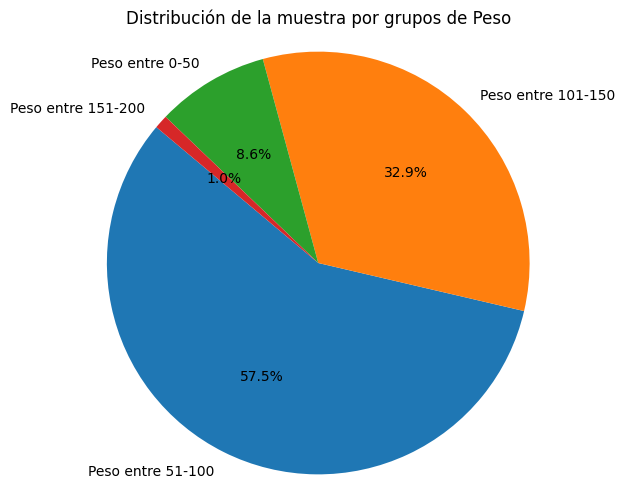

In [ ]:
# Definimos los grupos de pesos para el gráfico de pastel
bins = [0, 50, 100, 150, 200]

# Creamos las categorias para los grupos de pesos para el gráfico
categorias = ['Peso entre 0-50', 'Peso entre 51-100', 'Peso entre 101-150', 'Peso entre 151-200']

# Agrupamos los pesos, creamos una variable Grupo_pesos en donde le asignamos los pesos, pasando como arguementos
# los bins que definimos y las etiquetas que seran las categorias del gráfico
df['Grupo_Peso'] = pd.cut(df['Peso'], bins=bins, labels=categorias)

# Asignamos a la variable frecuencia por grupos los grupos de peso calculados
frecuencia_por_grupo = df['Grupo_Peso'].value_counts()

# Obtenemos las etiquetas de los grupos de pesos y las frecuencias
categorias = frecuencia_por_grupo.index
frecuencias = frecuencia_por_grupo.values

# Calculamos el porcentaje de cada grupo
porcentajes = frecuencias / frecuencias.sum() * 100

# Definimos el tamaño del lienzo
plt.figure(figsize=(6, 6))

# Definimos el gráfico de pie, pasamos argumentos como porcentajes que es la variable calculada, las etiquetas que son
# las categorias, autopct que nos prorporciona formato de punto flotante "float", startangle nos proporciona el angulo de
# inicio del gráfico en este caso comienza desde el angulo 140 grados, labeldistance nos permite controlar la distancia de las
# etiquetas.
plt.pie(porcentajes, labels=categorias, autopct='%1.1f%%', startangle=140, labeldistance=1.1)

# Titulo del gráfico
plt.title('Distribución de la muestra por grupos de Peso')

# Esto asegura que el gráfico sea un círculo en lugar de una elipse
plt.axis('equal')

# Imprimimos el gráfico
plt.show()

***INTERPRETACION***

  * El gráfico de pastel nos brinda una visión de la distribución de la muestra según grupos de peso predefinidos.
  * Los grupos de peso están divididos en rangos de 0-50, 51-100, 101-150 y 151-200 kilogramos.
  * El segmento con mayor representación en la muestra corresponde al grupo de peso entre 51 y 100 kilogramos, abarcando el 57.5% de todas las observaciones.
  * El segundo grupo más representativo es el de 101-150 kilogramos, comprendiendo el 32.9% de las observaciones.
  * Por otro lado, los grupos de peso de 0 a 50 kilogramos y de 151 a 200 kilogramos presentan una menor participación, representando solo el 8.6% y el 1% de las observaciones, respectivamente.

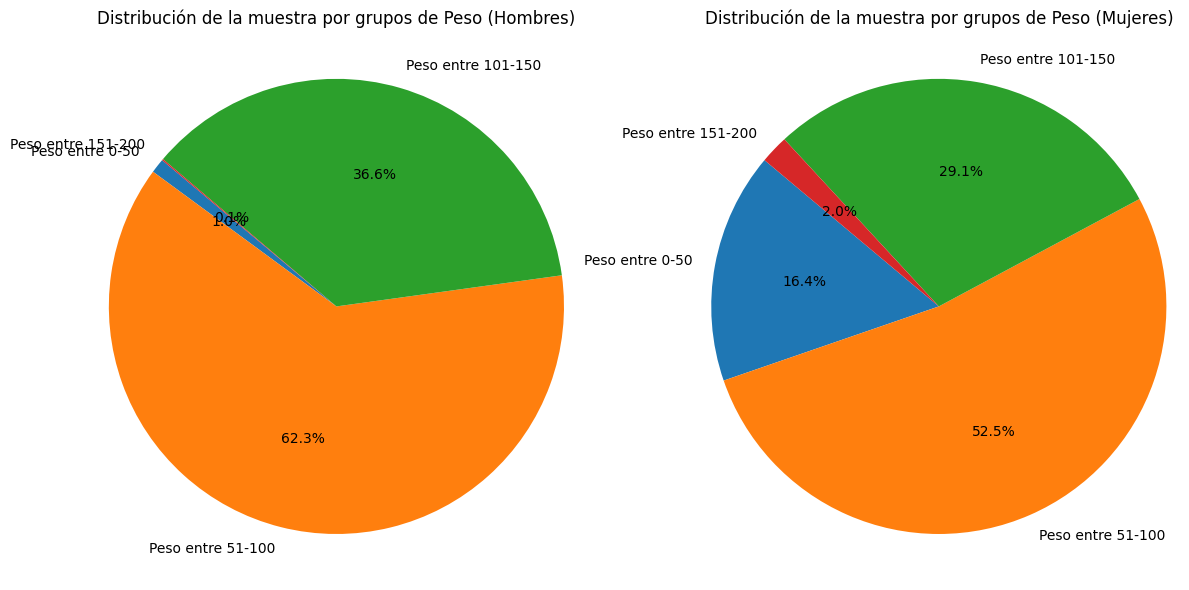

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # 1 fila, 2 columnas

# Asegurarse de que 'categorias' esté definida (de la celda b1Lgg0FsorLF)
categorias = ['Peso entre 0-50', 'Peso entre 51-100', 'Peso entre 101-150', 'Peso entre 151-200']
all_categorias_ordered = pd.Categorical(categorias, categories=categorias, ordered=True)

# --- Gráfico de Pastel por Género: Hombres ---

df_male = df[df['Género'] == 'Male']
frecuencia_por_grupo_male = df_male['Grupo_Peso'].value_counts()
frecuencia_por_grupo_male = frecuencia_por_grupo_male.reindex(all_categorias_ordered, fill_value=0)

# Solo calcular porcentajes si hay datos en df_male
if frecuencia_por_grupo_male.values.sum() > 0:
    porcentajes_male = frecuencia_por_grupo_male.values / frecuencia_por_grupo_male.values.sum() * 100
else:
    porcentajes_male = np.zeros(len(all_categorias_ordered))

axes[0].pie(porcentajes_male, labels=frecuencia_por_grupo_male.index, autopct='%1.1f%%', startangle=140, labeldistance=1.1)
axes[0].set_title('Distribución de la muestra por grupos de Peso (Hombres)')
axes[0].axis('equal') # Esto asegura que el gráfico sea un círculo en lugar de una elipse

# --- Gráfico de Pastel por Género: Mujeres ---

df_female = df[df['Género'] == 'Female']
frecuencia_por_grupo_female = df_female['Grupo_Peso'].value_counts()
frecuencia_por_grupo_female = frecuencia_por_grupo_female.reindex(all_categorias_ordered, fill_value=0)

# Solo calcular porcentajes si hay datos en df_female
if frecuencia_por_grupo_female.values.sum() > 0:
    porcentajes_female = frecuencia_por_grupo_female.values / frecuencia_por_grupo_female.values.sum() * 100
else:
    porcentajes_female = np.zeros(len(all_categorias_ordered))

axes[1].pie(porcentajes_female, labels=frecuencia_por_grupo_female.index, autopct='%1.1f%%', startangle=140, labeldistance=1.1)
axes[1].set_title('Distribución de la muestra por grupos de Peso (Mujeres)')
axes[1].axis('equal') # Esto asegura que el gráfico sea un círculo en lugar de una elipse

plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado
plt.show()